Setup & Load Imbalanced Dataset

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score
)
from sklearn.datasets import fetch_openml
from imblearn.over_sampling import SMOTE
import gradio as gr
import joblib
import wandb

# Inisialisasi W&B untuk tracking eksperimen
run = wandb.init(project="credit-card-fraud-detection", name="xgboost-smote-real-imbalance")

print("Sedang mengambil dataset asli (imbalanced) dari OpenML...")
# ID 1597 adalah dataset Credit Card Fraud asli yang sangat timpang (284.807 baris)
data = fetch_openml(data_id=1597, as_frame=True, parser='auto')

# Menggabungkan data
df = pd.concat([data.data, data.target], axis=1)
df.columns = [*df.columns[:-1], 'Class']
df['Class'] = df['Class'].astype(int)

# Untuk efisiensi waktu kelas, kita ambil sample 50.000 data namun tetap menjaga ketimpangannya
df = df.sample(n=50000, random_state=42)

print(f"Dataset Berhasil Dimuat! Shape: {df.shape}")
print("\nProporsi Kelas Asli (SANGAT TIMPANG):")
print(df['Class'].value_counts()) # Lihat angka aslinya
print(df['Class'].value_counts(normalize=True)) # Lihat persentasenya

# Log sampel ke W&B
wandb.log({"raw_sample": wandb.Table(dataframe=df.head(100))})

Sedang mengambil dataset asli (imbalanced) dari OpenML...
Dataset Berhasil Dimuat! Shape: (50000, 30)

Proporsi Kelas Asli (SANGAT TIMPANG):
Class
0    49917
1       83
Name: count, dtype: int64
Class
0    0.99834
1    0.00166
Name: proportion, dtype: float64


Visualisasi Masalah Imbalance



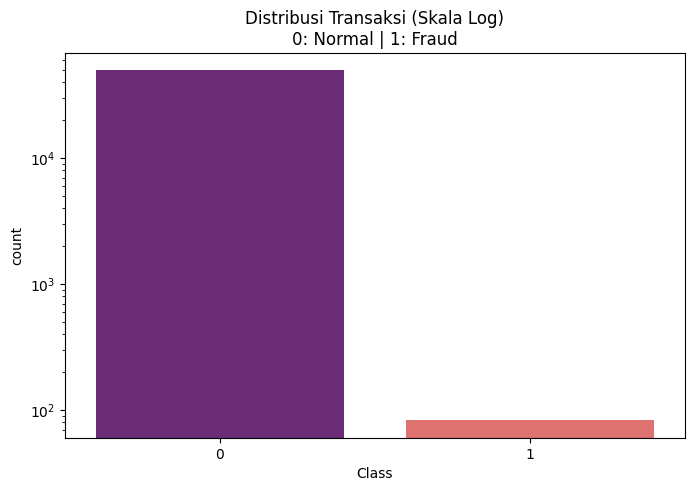

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='magma', hue='Class', legend=False)
plt.title("Distribusi Transaksi (Skala Log)\n0: Normal | 1: Fraud")
plt.yscale('log') # Skala log digunakan agar kelas minoritas (Fraud) terlihat jelas
plt.show()

Handling Imbalance dengan SMOTE

In [3]:
X = df.drop(columns=['Class'])
y = df['Class']

# Menggunakan stratify agar proporsi kelas di data latih dan uji tetap sama
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nMenjalankan SMOTE untuk menyeimbangkan data...")
# SMOTE menciptakan data 'Fraud' sintetis agar AI belajar pola penipuan
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Jumlah data setelah SMOTE: {len(y_train_res)}")
print(f"Proporsi kelas setelah SMOTE (Sudah Seimbang 50:50): \n{pd.Series(y_train_res).value_counts(normalize=True)}")


Menjalankan SMOTE untuk menyeimbangkan data...
Jumlah data setelah SMOTE: 79868
Proporsi kelas setelah SMOTE (Sudah Seimbang 50:50): 
Class
0    0.5
1    0.5
Name: proportion, dtype: float64


Visualisasi Efek SMOTE

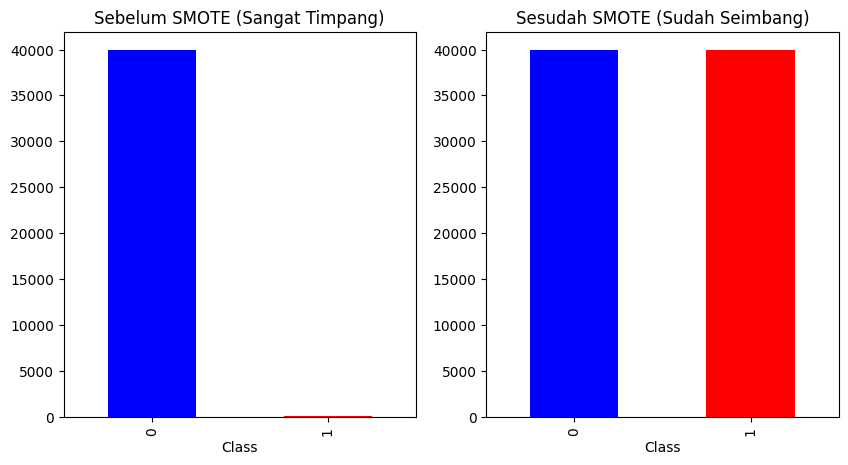

In [4]:
# Bandingkan jumlah data sebelum vs sesudah SMOTE secara visual
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("Sebelum SMOTE (Sangat Timpang)")

plt.subplot(1, 2, 2)
pd.Series(y_train_res).value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("Sesudah SMOTE (Sudah Seimbang)")
plt.show()

TRAINING RANDOM FOREST (BAGGING)

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)

# Prediksi Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Hitung metrik
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auprc = average_precision_score(y_test, y_prob_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)

print("\n--- HASIL EVALUASI RANDOM FOREST ---")
print(f"Accuracy Score : {rf_accuracy:.4f}")
print(f"AUPRC Score    : {rf_auprc:.4f}")
print(f"Precision      : {rf_precision:.4f}")
print(f"Recall         : {rf_recall:.4f}")
print("\nClassification Report Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Log ke W&B
wandb.log({
    "RF_Accuracy_Score": rf_accuracy,
    "RF_AUPRC_Score": rf_auprc,
    "RF_Precision_Score": rf_precision,
    "RF_Recall_Score": rf_recall
})


--- HASIL EVALUASI RANDOM FOREST ---
Accuracy Score : 0.9993
AUPRC Score    : 0.6775
Precision      : 0.8571
Recall         : 0.7059

Classification Report Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.86      0.71      0.77        17

    accuracy                           1.00     10000
   macro avg       0.93      0.85      0.89     10000
weighted avg       1.00      1.00      1.00     10000



CONFUSION MATRIX RANDOM FOREST

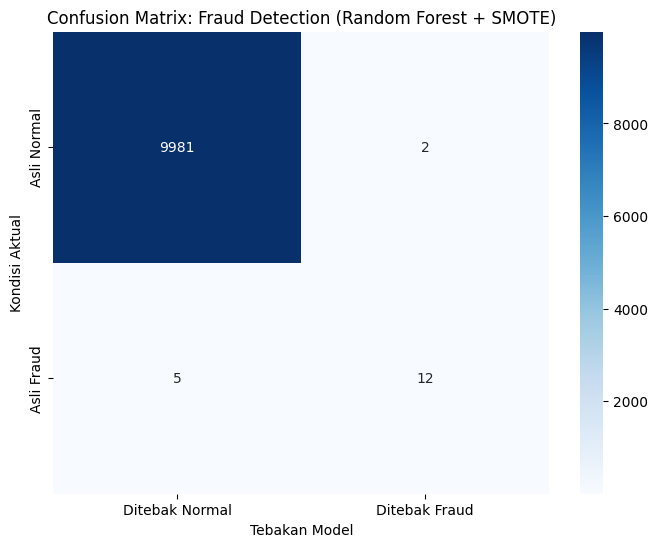

In [6]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ditebak Normal', 'Ditebak Fraud'],
    yticklabels=['Asli Normal', 'Asli Fraud']
)
plt.title("Confusion Matrix: Fraud Detection (Random Forest + SMOTE)")
plt.ylabel("Kondisi Aktual")
plt.xlabel("Tebakan Model")
plt.show()

Training XGBoost & Evaluasi AUPRC

In [7]:
# XGBoost adalah algoritma 'Boosting' yang memperbaiki kesalahan secara bertahap
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_res, y_train_res)

# Prediksi probabilitas
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Hitung metrik
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprc = average_precision_score(y_test, y_prob)
xgb_precision = precision_score(y_test, y_pred)
xgb_recall = recall_score(y_test, y_pred)

print("\n--- HASIL EVALUASI XGBOOST ---")
print(f"Accuracy Score : {xgb_accuracy:.4f}")
print(f"AUPRC Score    : {xgb_auprc:.4f}")
print(f"Precision      : {xgb_precision:.4f}")
print(f"Recall         : {xgb_recall:.4f}")
print("\nClassification Report XGBoost:")
print(classification_report(y_test, y_pred))

# Log ke W&B
wandb.log({
    "XGB_Accuracy_Score": xgb_accuracy,
    "XGB_AUPRC_Score": xgb_auprc,
    "XGB_Precision_Score": xgb_precision,
    "XGB_Recall_Score": xgb_recall
})


--- HASIL EVALUASI XGBOOST ---
Accuracy Score : 0.9989
AUPRC Score    : 0.6843
Precision      : 0.6500
Recall         : 0.7647

Classification Report XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.65      0.76      0.70        17

    accuracy                           1.00     10000
   macro avg       0.82      0.88      0.85     10000
weighted avg       1.00      1.00      1.00     10000



Visualisasi Confusion Matrix

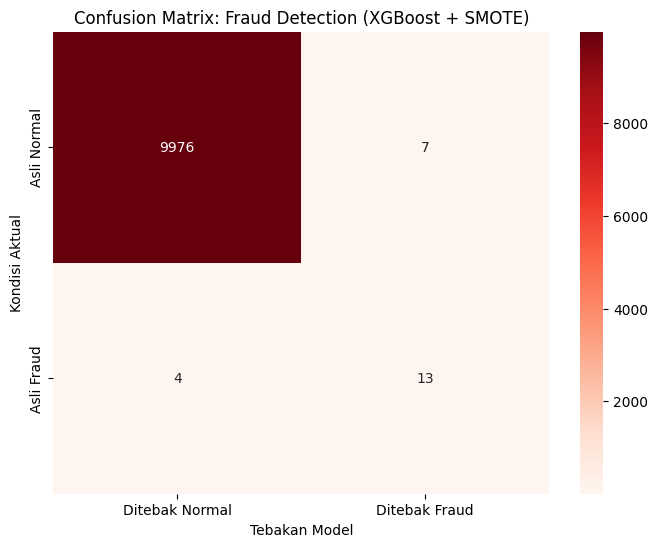

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ditebak Normal', 'Ditebak Fraud'],
            yticklabels=['Asli Normal', 'Asli Fraud'])
plt.title("Confusion Matrix: Fraud Detection (XGBoost + SMOTE)")
plt.ylabel("Kondisi Aktual")
plt.xlabel("Tebakan Model")
plt.show()

FEATURE IMPORTANCE RANDOM FOREST

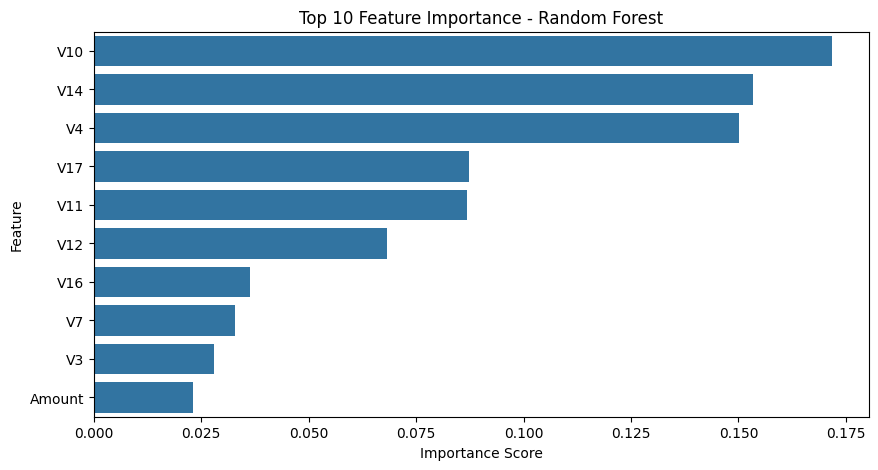

In [9]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=rf_importance.values, y=rf_importance.index)
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

Feature Importance XGBoost

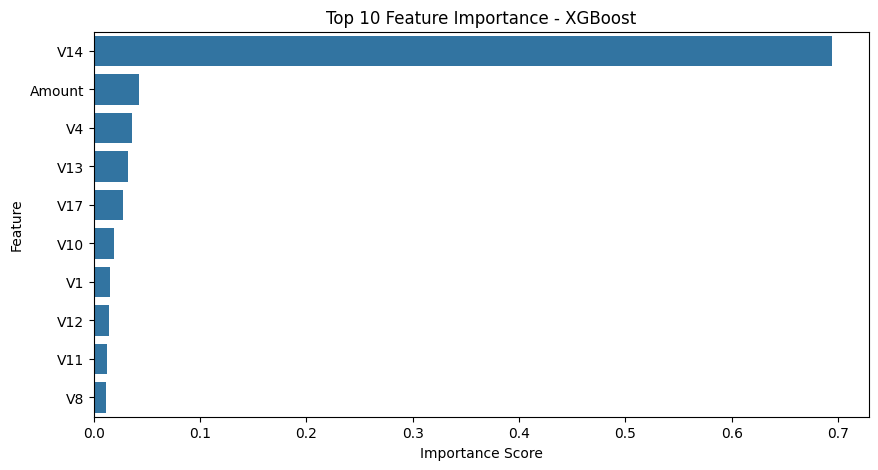

In [10]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=xgb_importance.values, y=xgb_importance.index)
plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [11]:
wandb.finish()

RF_AUPRC_Score,▁
RF_Accuracy_Score,▁
RF_Precision_Score,▁
RF_Recall_Score,▁
XGB_AUPRC_Score,▁
XGB_Accuracy_Score,▁
XGB_Precision_Score,▁
XGB_Recall_Score,▁
RF_AUPRC_Score,0.67752
RF_Accuracy_Score,0.9993
RF_Precision_Score,0.85714


In [12]:
# Simpan model penipuan yang benar
joblib.dump(xgb_model, 'fraud_detection_model.pkl')
print("Model Berhasil Disimpan!")

# Load model
model = joblib.load('fraud_detection_model.pkl')

# Ambil rata-rata fitur V1-V28 untuk placeholder input yang tidak dimasukkan user
feature_means = X_train.mean().values

def predict_fraud_fixed(time_input, amount, v1_value, v2_value):
    try:
        # Menyiapkan array sesuai ukuran asli model (29 fitur)
        input_data = feature_means.copy()

        # Jika size adalah 29, maka indeks terakhir adalah 28
        # Kita asumsikan urutannya adalah V1, V2, ..., V28, Amount
        input_data[0] = v1_value   # Indeks 0 untuk V1
        input_data[1] = v2_value   # Indeks 1 untuk V2
        input_data[-1] = amount    # Indeks terakhir untuk Amount (index 28)

        # Catatan: Jika error tetap muncul, kolom 'Time' mungkin tidak digunakan oleh model Anda

        features = input_data.reshape(1, -1)
        prediction = model.predict(features)[0]
        probability = model.predict_proba(features)[0][1]

        if prediction == 1:
            return f"🚨 TERDETEKSI FRAUD! (Probabilitas: {probability:.2%})"
        else:
            return f"✅ TRANSAKSI AMAN (Probabilitas Fraud: {probability:.2%})"

    except Exception as e:
        return f"❌ Kesalahan sistem: {str(e)}"

# Update Interface
demo = gr.Interface(
    fn=predict_fraud_fixed,
    inputs=[
        gr.Number(label="Waktu (Bisa diisi 0 jika tidak digunakan)"),
        gr.Number(label="Jumlah Transaksi (Amount)"),
        gr.Slider(-50, 50, label="Indikator PCA V1"),
        gr.Slider(-50, 50, label="Indikator PCA V2")
    ],
    outputs="text",
    title="💳 Sistem Deteksi Penipuan Kartu Kredit"
)
demo.launch()

Model Berhasil Disimpan!
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://81d63857eef8a1f1aa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
